# 01 Dataset Overview

Progress-phase notebook for dataset inspection, EEG file detection, metadata creation, and class-distribution visualization.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from dataset_loader import create_subject_metadata, scan_eeg_files
from utils import RAW_DATASET_DIR

In [2]:
print('Dataset directory:', RAW_DATASET_DIR)
print('Dataset exists:', RAW_DATASET_DIR.exists())
print('participants.tsv exists:', (RAW_DATASET_DIR / 'participants.tsv').exists())
eeg_files = scan_eeg_files(RAW_DATASET_DIR)
print('Total EEG files detected recursively:', len(eeg_files))
print('Sample EEG paths:')
for path in eeg_files[:5]:
    print(' -', path)

Dataset directory: D:\2026 MTECH Project\alz_project\data\raw\ds004504
Dataset exists: True
participants.tsv exists: True
Total EEG files detected recursively: 176
Sample EEG paths:
 - D:\2026 MTECH Project\alz_project\data\raw\ds004504\sub-001\eeg\sub-001_task-eyesclosed_eeg.set
 - D:\2026 MTECH Project\alz_project\data\raw\ds004504\sub-002\eeg\sub-002_task-eyesclosed_eeg.set
 - D:\2026 MTECH Project\alz_project\data\raw\ds004504\sub-003\eeg\sub-003_task-eyesclosed_eeg.set
 - D:\2026 MTECH Project\alz_project\data\raw\ds004504\sub-004\eeg\sub-004_task-eyesclosed_eeg.set
 - D:\2026 MTECH Project\alz_project\data\raw\ds004504\sub-005\eeg\sub-005_task-eyesclosed_eeg.set


In [3]:
metadata_df = create_subject_metadata(RAW_DATASET_DIR)
metadata_df.head()

[alz_project] Total EEG files detected: 176
[alz_project] Total matched subjects: 88
[alz_project] Class distribution: {'AD': 36, 'CN': 29, 'FTD': 23}
[alz_project] Sample EEG files: ['data\\raw\\ds004504\\sub-001\\eeg\\sub-001_task-eyesclosed_eeg.set', 'data\\raw\\ds004504\\sub-002\\eeg\\sub-002_task-eyesclosed_eeg.set', 'data\\raw\\ds004504\\sub-003\\eeg\\sub-003_task-eyesclosed_eeg.set', 'data\\raw\\ds004504\\sub-004\\eeg\\sub-004_task-eyesclosed_eeg.set', 'data\\raw\\ds004504\\sub-005\\eeg\\sub-005_task-eyesclosed_eeg.set']


,subject_id,label,class_name,eeg_file
0,sub-001,0,AD,data\raw\ds004504\sub-001\eeg\sub-001_task-eye...
1,sub-002,0,AD,data\raw\ds004504\sub-002\eeg\sub-002_task-eye...
2,sub-003,0,AD,data\raw\ds004504\sub-003\eeg\sub-003_task-eye...
3,sub-004,0,AD,data\raw\ds004504\sub-004\eeg\sub-004_task-eye...
4,sub-005,0,AD,data\raw\ds004504\sub-005\eeg\sub-005_task-eye...


In [4]:
print('Total matched subjects:', len(metadata_df))
print('Expected subject count check against 88:', 'MATCH' if len(metadata_df) == 88 else 'DIFFERS')
class_counts = metadata_df['class_name'].value_counts().sort_index()
class_counts

Total matched subjects: 88
Expected subject count check against 88: MATCH


class_name
AD     36
CN     29
FTD    23
Name: count, dtype: int64

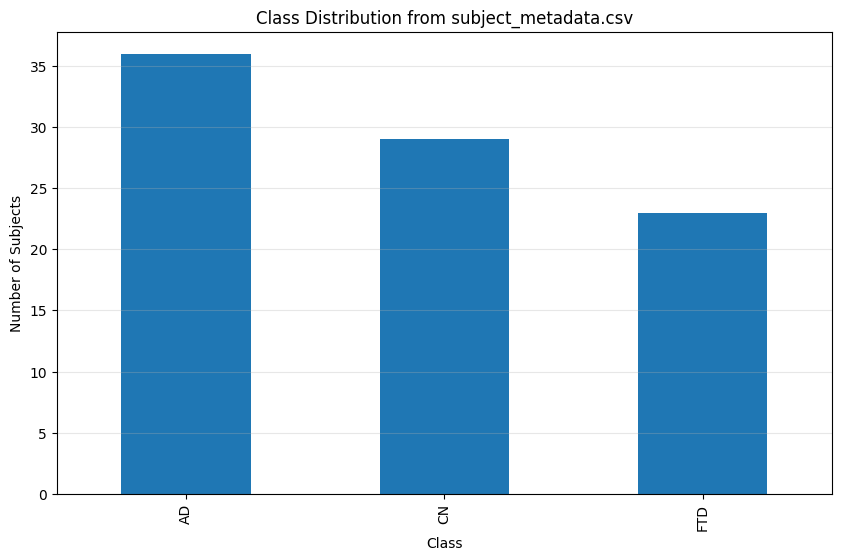

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution from subject_metadata.csv')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Subjects')
ax.grid(True, axis='y', alpha=0.3)
plt.show()